# Selection filter experiment

Cheap filter sweep on BDD100K with a lightweight regime stream.

This notebook compares the stock selection knobs first:

- B-floor (`AcceptAll`)
- reservoir replay
- SemDeDup
- loss-gate

The stream uses the real BDD100K image/attribute layout. `max_images` caps how much of BDD is loaded, and `max_train_per_regime` caps how many training images each regime contributes. Set either one to `None` to disable that cap. The notebook also picks CUDA automatically when available and falls back to CPU if it is not.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import torch
from hydra.utils import instantiate
from loguru import logger
from omegaconf import OmegaConf

logger.remove()
logger.add(sys.stderr, level="WARNING")

device = "cuda" if torch.cuda.is_available() else "cpu"
bdd_root = Path("D:/AI Proj/bdd100k_images_100k")
bdd_split = "val"
max_images = 4000
repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").is_file():
    if repo_root.parent == repo_root:
        raise RuntimeError("Could not find the repository root from the current working directory.")
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from cafl4ds.data.attributes import BDD100KSource
from cafl4ds.data.regime import RegimeStream
from cafl4ds.data.streams import StreamBatch
from cafl4ds.filters.accept_all import AcceptAll
from cafl4ds.filters.base import Filter, FilterContext
from cafl4ds.filters.composite import CompositeSelector
from cafl4ds.filters.dedup import SemDeDup
from cafl4ds.filters.loss_gate import LossGate
from cafl4ds.filters.reservoir import ReservoirReplay
from cafl4ds.harness import run_stream_arm
from cafl4ds.monitor import HealthMonitor
from cafl4ds.ssl.base import apply_encoder_init

seed = 0
img_size = 64
batch_size = 16
support_per_canary = 25
query_per_canary = 25
era_query_per_cell = 5
max_train_per_regime = 32
eval_every = 4
min_canary_count = 50

encoder_cfg = OmegaConf.create(
    {
        "_target_": "cafl4ds.models.vit.TinyViTEncoder",
        "img_size": img_size,
        "patch_size": 8,
        "in_chans": 3,
        "embed_dim": 96,
        "depth": 4,
        "num_heads": 3,
        "mlp_ratio": 2.0,
    }
)
ssl_cfg = OmegaConf.create(
    {
        "_target_": "cafl4ds.ssl.factory.build_simsiam",
        "proj_hidden": 256,
        "proj_dim": 128,
        "pred_hidden": 64,
        "anti_collapse": True,
    }
)
optimizer_cfg = OmegaConf.create({"_target_": "torch.optim.AdamW", "lr": 1e-3, "weight_decay": 0.05})


def build_stream(stream_seed: int = seed) -> RegimeStream:
    source = BDD100KSource(
        bdd_root=str(bdd_root),
        split=bdd_split,
        img_size=img_size,
        max_images=max_images,
        min_canary_count=min_canary_count,
    )
    return RegimeStream(
        source=source,
        batch_size=batch_size,
        support_per_canary=support_per_canary,
        query_per_canary=query_per_canary,
        era_query_per_cell=era_query_per_cell,
        max_train_per_regime=max_train_per_regime,
        seed=stream_seed,
        canary_seed=0,
    )


def build_method(method_seed: int = seed):
    torch.manual_seed(method_seed)
    encoder = instantiate(encoder_cfg)
    method = instantiate(ssl_cfg, encoder=encoder)
    apply_encoder_init(method.encoder, "from_scratch", None)
    return method


def build_monitor(stream: RegimeStream) -> HealthMonitor:
    return HealthMonitor(eval_sets=stream.eval_sets, knn_k=20, run_knn=True, run_linear=True, run_alignment=True, align_seed=0)


def build_optimizer(method):
    return instantiate(optimizer_cfg, params=method.parameters())


class RecordingFilter(Filter):
    def __init__(self, inner: Filter) -> None:
        self.inner = inner
        self.seen_images = 0
        self.kept_images = 0

    def select(self, batch: StreamBatch, ctx: FilterContext) -> torch.Tensor:
        accepted = self.inner.select(batch, ctx)
        self.seen_images += batch.images.shape[0]
        self.kept_images += accepted.shape[0]
        return accepted

    def auxiliary_loss(self, images: torch.Tensor, ctx: FilterContext) -> torch.Tensor | None:
        return self.inner.auxiliary_loss(images, ctx)

    def stats(self) -> dict[str, float | int]:
        stats: dict[str, float | int] = {
            "seen_images": self.seen_images,
            "kept_images": self.kept_images,
            "keep_fraction": self.kept_images / self.seen_images if self.seen_images else 0.0,
        }
        if isinstance(self.inner, CompositeSelector):
            for index, stage in enumerate(self.inner.admission):
                if hasattr(stage, "stats"):
                    stats.update({f"admission{index}_{key}": value for key, value in stage.stats().items()})
            if self.inner.buffer is not None and hasattr(self.inner.buffer, "stats"):
                stats.update({f"buffer_{key}": value for key, value in self.inner.buffer.stats().items()})
        elif hasattr(self.inner, "stats"):
            stats.update(self.inner.stats())
        return stats


def make_selector(name: str, run_seed: int = seed) -> Filter:
    if name == "b_floor":
        return AcceptAll()
    if name == "reservoir":
        return CompositeSelector(buffer=ReservoirReplay(capacity=32, replay_batch=batch_size, seed=run_seed))
    if name == "dedup":
        return SemDeDup(threshold=0.9)
    if name == "loss_gate":
        return LossGate(keep_frac=0.5)
    if name == "dedup_reservoir":
        return CompositeSelector(
            admission=[SemDeDup(threshold=0.9)],
            buffer=ReservoirReplay(capacity=32, replay_batch=batch_size, seed=run_seed),
        )
    raise KeyError(f"Unknown selector {name!r}")


def summarize_arm(arm) -> dict[str, float | int | bool | None]:
    health = arm.health
    final = health[-1] if health else {}
    return {
        "health_points": len(health),
        "final_step": final.get("step"),
        "final_era": final.get("era"),
        "final_knn_acc": final.get("knn_acc"),
        "final_linear_acc": final.get("linear_acc"),
        "final_rankme": final.get("rankme"),
        "final_cosine_drift": final.get("cosine_drift"),
        "min_loss": arm.loss_floor,
        "diverged": arm.diverged,
    }


In [2]:
def run_selector(name: str, run_seed: int = seed):
    stream = build_stream(run_seed)
    method = build_method(run_seed)
    selector = RecordingFilter(make_selector(name, run_seed))
    out_dir = repo_root / "outputs" / "filter-selection" / name
    out_dir.mkdir(parents=True, exist_ok=True)
    arm = run_stream_arm(
        name=f"{name}_live",
        role="live",
        method=method,
        stream=stream,
        optimizer=build_optimizer(method),
        selection_filter=selector,
        monitor=build_monitor(stream),
        out_dir=out_dir,
        eval_every=eval_every,
        device=device,
    )
    summary = summarize_arm(arm)
    summary.update({"filter": name, **selector.stats()})
    return arm, summary


filter_specs = ["b_floor", "reservoir", "dedup", "loss_gate"]

In [3]:
results = []


def fmt(value, spec):
    return "n/a" if value is None else format(value, spec)


for selector_name in filter_specs:
    arm, summary = run_selector(selector_name)
    results.append({"name": selector_name, **summary})
    print(
        f"{selector_name:<12} "
        f"keep={fmt(summary['keep_fraction'], '.2f')} "
        f"min_loss={fmt(summary['min_loss'], '.4f')} "
        f"knn={fmt(summary['final_knn_acc'], '.3f')} "
        f"linear={fmt(summary['final_linear_acc'], '.3f')} "
        f"rankme={fmt(summary['final_rankme'], '.3f')} "
        f"drift={fmt(summary['final_cosine_drift'], '.3f')}"
    )

results

b_floor      keep=1.00 min_loss=-0.7556 knn=0.387 linear=0.427 rankme=2.549 drift=0.647
reservoir    keep=2.17 min_loss=-0.6955 knn=0.440 linear=0.507 rankme=2.394 drift=0.327
dedup        keep=0.09 min_loss=-0.0928 knn=0.387 linear=0.373 rankme=3.818 drift=0.000
loss_gate    keep=0.50 min_loss=-0.4494 knn=0.333 linear=0.467 rankme=3.430 drift=0.549


[{'name': 'b_floor',
  'health_points': 8,
  'final_step': 29.0,
  'final_era': 17,
  'final_knn_acc': 0.38666666666666666,
  'final_linear_acc': 0.4266666666666667,
  'final_rankme': 2.548701763153076,
  'final_cosine_drift': 0.6466233730316162,
  'min_loss': -0.75563645362854,
  'diverged': False,
  'filter': 'b_floor',
  'seen_images': 398,
  'kept_images': 398,
  'keep_fraction': 1.0},
 {'name': 'reservoir',
  'health_points': 9,
  'final_step': 29.0,
  'final_era': 17,
  'final_knn_acc': 0.44,
  'final_linear_acc': 0.5066666666666667,
  'final_rankme': 2.3938100337982178,
  'final_cosine_drift': 0.32654958963394165,
  'min_loss': -0.6955471038818359,
  'diverged': False,
  'filter': 'reservoir',
  'seen_images': 398,
  'kept_images': 862,
  'keep_fraction': 2.1658291457286434},
 {'name': 'dedup',
  'health_points': 1,
  'final_step': 28.0,
  'final_era': 16,
  'final_knn_acc': 0.38666666666666666,
  'final_linear_acc': 0.37333333333333335,
  'final_rankme': 3.8180253505706787,
  '

## How to read the BDD run

The table below already tells you whether each filter kept the stream flowing.
The plots make the trade-off easier to see:

- `keep_fraction` shows how selective the filter is.
- `final_knn_acc` and `final_linear_acc` show whether the learned representation stayed useful.
- `final_rankme` and `final_cosine_drift` are the health signals. They show whether the representation stayed spread out or started moving a lot.

On BDD100K, `max_images` is the loader cap and `max_train_per_regime` is the training cap. Set either one to `None` to disable that cap. `SemDeDup` is still the most aggressive filter, while `reservoir` increases the effective batch by replaying past frames.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

summary_df = pd.DataFrame(results).set_index("name")
show_cols = [
    "keep_fraction",
    "min_loss",
    "final_knn_acc",
    "final_linear_acc",
    "final_rankme",
    "final_cosine_drift",
]

summary_df[show_cols]


,keep_fraction,min_loss,final_knn_acc,final_linear_acc,final_rankme,final_cosine_drift
name,,,,,,
b_floor,1.000000,-0.755636,0.386667,0.426667,2.548702,0.646623
reservoir,2.165829,-0.695547,0.440000,0.506667,2.393810,0.326550
dedup,0.090452,-0.092782,0.386667,0.373333,3.818025,0.000000
loss_gate,0.502513,-0.449410,0.333333,0.466667,3.430151,0.549127


Text(0.5, 0.98, 'Cheap filter comparison on BDD100K')

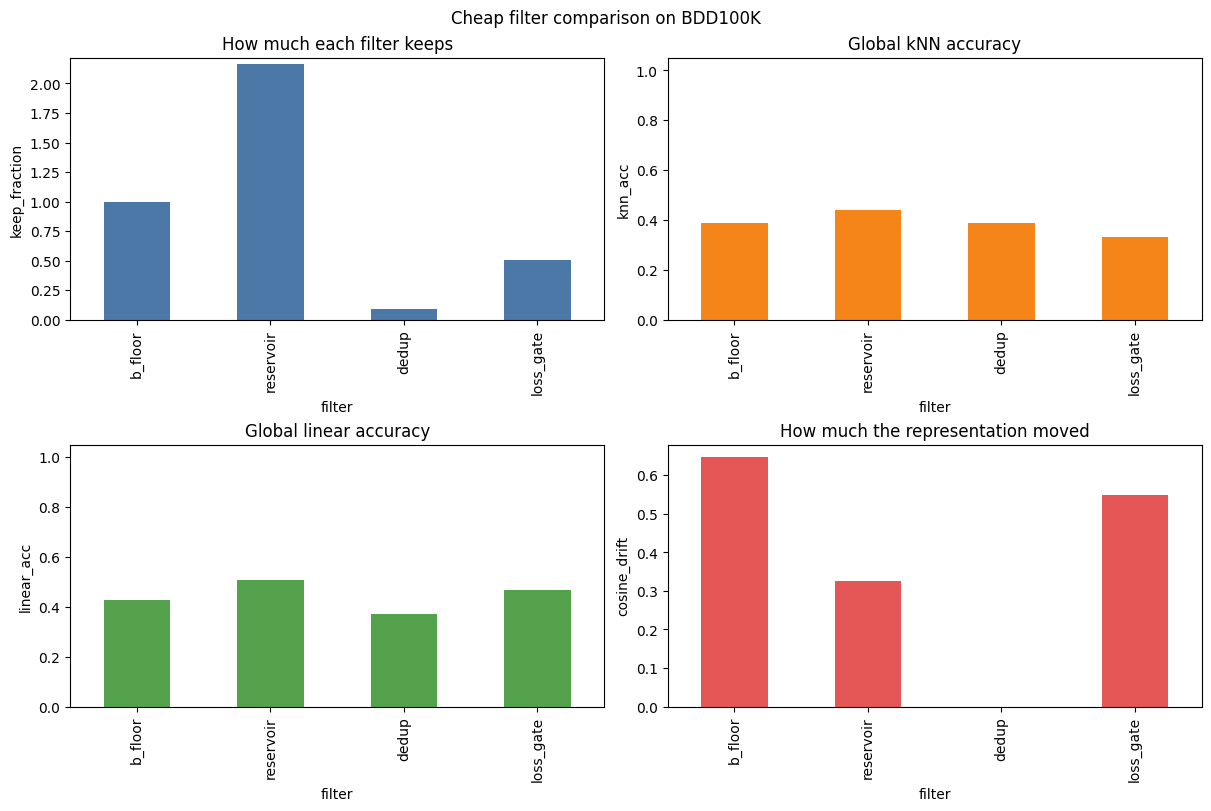

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

summary_df["keep_fraction"].plot(kind="bar", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("How much each filter keeps")
axes[0, 0].set_xlabel("filter")
axes[0, 0].set_ylabel("keep_fraction")
axes[0, 0].set_ylim(0, max(1.05, float(summary_df["keep_fraction"].max()) + 0.05))

summary_df["final_knn_acc"].plot(kind="bar", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Global kNN accuracy")
axes[0, 1].set_xlabel("filter")
axes[0, 1].set_ylabel("knn_acc")
axes[0, 1].set_ylim(0, 1.05)

summary_df["final_linear_acc"].plot(kind="bar", ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Global linear accuracy")
axes[1, 0].set_xlabel("filter")
axes[1, 0].set_ylabel("linear_acc")
axes[1, 0].set_ylim(0, 1.05)

summary_df["final_cosine_drift"].plot(kind="bar", ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("How much the representation moved")
axes[1, 1].set_xlabel("filter")
axes[1, 1].set_ylabel("cosine_drift")

fig.suptitle("Cheap filter comparison on BDD100K")

## Uncapped follow-up

Reservoir looked like the strongest cheap filter in the capped run, so this follow-up removes both limits for that one setting only.

Here, `max_images = None` and `max_train_per_regime = None` mean:
- load the full BDD validation source instead of the capped slice;
- let every regime contribute all available training images.

This is the right place to look at the trajectory, not just the final readout.

In [6]:
uncapped_max_images = None
uncapped_max_train_per_regime = None


def build_uncapped_stream(stream_seed: int = seed) -> RegimeStream:
    source = BDD100KSource(
        bdd_root=str(bdd_root),
        split=bdd_split,
        img_size=img_size,
        max_images=uncapped_max_images,
        min_canary_count=min_canary_count,
    )
    return RegimeStream(
        source=source,
        batch_size=batch_size,
        support_per_canary=support_per_canary,
        query_per_canary=query_per_canary,
        era_query_per_cell=era_query_per_cell,
        max_train_per_regime=uncapped_max_train_per_regime,
        seed=stream_seed,
        canary_seed=0,
    )


def run_uncapped_selector(name: str = "reservoir", run_seed: int = seed):
    stream = build_uncapped_stream(run_seed)
    method = build_method(run_seed)
    selector = RecordingFilter(make_selector(name, run_seed))
    out_dir = repo_root / "outputs" / "filter-selection" / f"{name}_uncapped"
    out_dir.mkdir(parents=True, exist_ok=True)
    arm = run_stream_arm(
        name=f"{name}_uncapped_live",
        role="live",
        method=method,
        stream=stream,
        optimizer=build_optimizer(method),
        selection_filter=selector,
        monitor=build_monitor(stream),
        out_dir=out_dir,
        eval_every=eval_every,
        device=device,
    )
    summary = summarize_arm(arm)
    summary.update(
        {
            "filter": name,
            "max_images": uncapped_max_images,
            "max_train_per_regime": uncapped_max_train_per_regime,
            **selector.stats(),
        }
    )
    return arm, summary


uncapped_arm, uncapped_summary = run_uncapped_selector("reservoir")
uncapped_summary

{'health_points': 135,
 'final_step': 534.0,
 'final_era': 17,
 'final_knn_acc': 0.4666666666666667,
 'final_linear_acc': 0.5333333333333333,
 'final_rankme': 1.7943592071533203,
 'final_cosine_drift': 0.28361040353775024,
 'min_loss': -0.9889962673187256,
 'diverged': False,
 'filter': 'reservoir',
 'max_images': None,
 'max_train_per_regime': None,
 'seen_images': 8393,
 'kept_images': 16937,
 'keep_fraction': 2.0179911831287978}

The comparison above is the important readout: if the uncapped run changes the final metrics but also bends the curve shapes, then the filter is affecting the training dynamics, not just the endpoint.

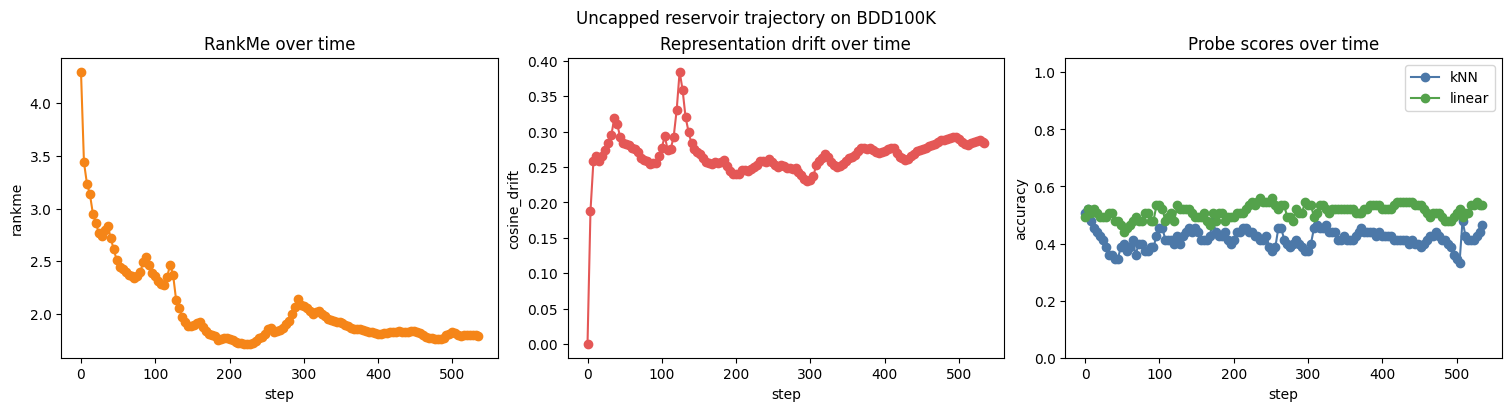

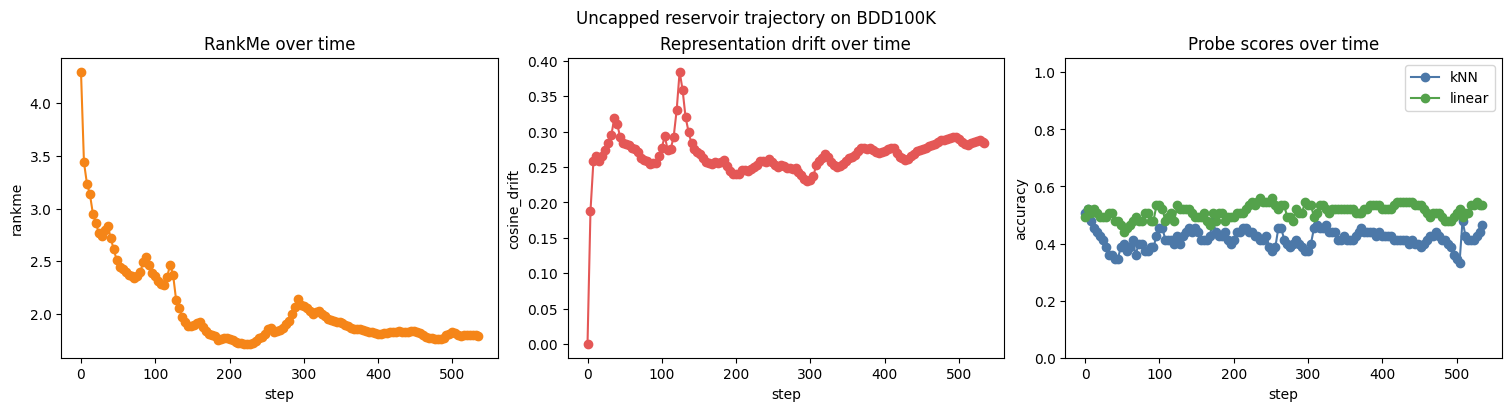

In [7]:
uncapped_health_df = pd.DataFrame(uncapped_arm.health)
if not uncapped_health_df.empty:
    uncapped_health_df = uncapped_health_df.sort_values("step")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

if not uncapped_health_df.empty:
    axes[0].plot(uncapped_health_df["step"], uncapped_health_df["rankme"], marker="o", color="#F58518")
    axes[0].set_title("RankMe over time")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("rankme")

    axes[1].plot(uncapped_health_df["step"], uncapped_health_df["cosine_drift"], marker="o", color="#E45756")
    axes[1].set_title("Representation drift over time")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("cosine_drift")

    axes[2].plot(uncapped_health_df["step"], uncapped_health_df["knn_acc"], marker="o", label="kNN", color="#4C78A8")
    axes[2].plot(uncapped_health_df["step"], uncapped_health_df["linear_acc"], marker="o", label="linear", color="#54A24B")
    axes[2].set_title("Probe scores over time")
    axes[2].set_xlabel("step")
    axes[2].set_ylabel("accuracy")
    axes[2].set_ylim(0, 1.05)
    axes[2].legend()

fig.suptitle("Uncapped reservoir trajectory on BDD100K")
fig

In [8]:
capped_reservoir_summary = summary_df.loc["reservoir"].to_dict()
uncapped_health_df = pd.DataFrame(uncapped_arm.health)
if not uncapped_health_df.empty:
    uncapped_health_df = uncapped_health_df.sort_values("step")

comparison_df = pd.DataFrame(
    [
        {"setting": "capped reservoir", **capped_reservoir_summary},
        {"setting": "uncapped reservoir", **uncapped_summary},
    ]
).set_index("setting")

comparison_df[["keep_fraction", "final_knn_acc", "final_linear_acc", "final_rankme", "final_cosine_drift", "min_loss"]]

,keep_fraction,final_knn_acc,final_linear_acc,final_rankme,final_cosine_drift,min_loss
setting,,,,,,
capped reservoir,2.165829,0.440000,0.506667,2.393810,0.32655,-0.695547
uncapped reservoir,2.017991,0.466667,0.533333,1.794359,0.28361,-0.988996


The line plots above are the main comparison. The trajectory plot below is checkpoint-aligned, so it compares the same health-order position across filters even when they emit different numbers of checkpoints. If a filter only changes the final bars but leaves the curve shape intact, it is mostly changing the endpoint. If it bends the curves early or late, it is changing the training dynamics themselves.

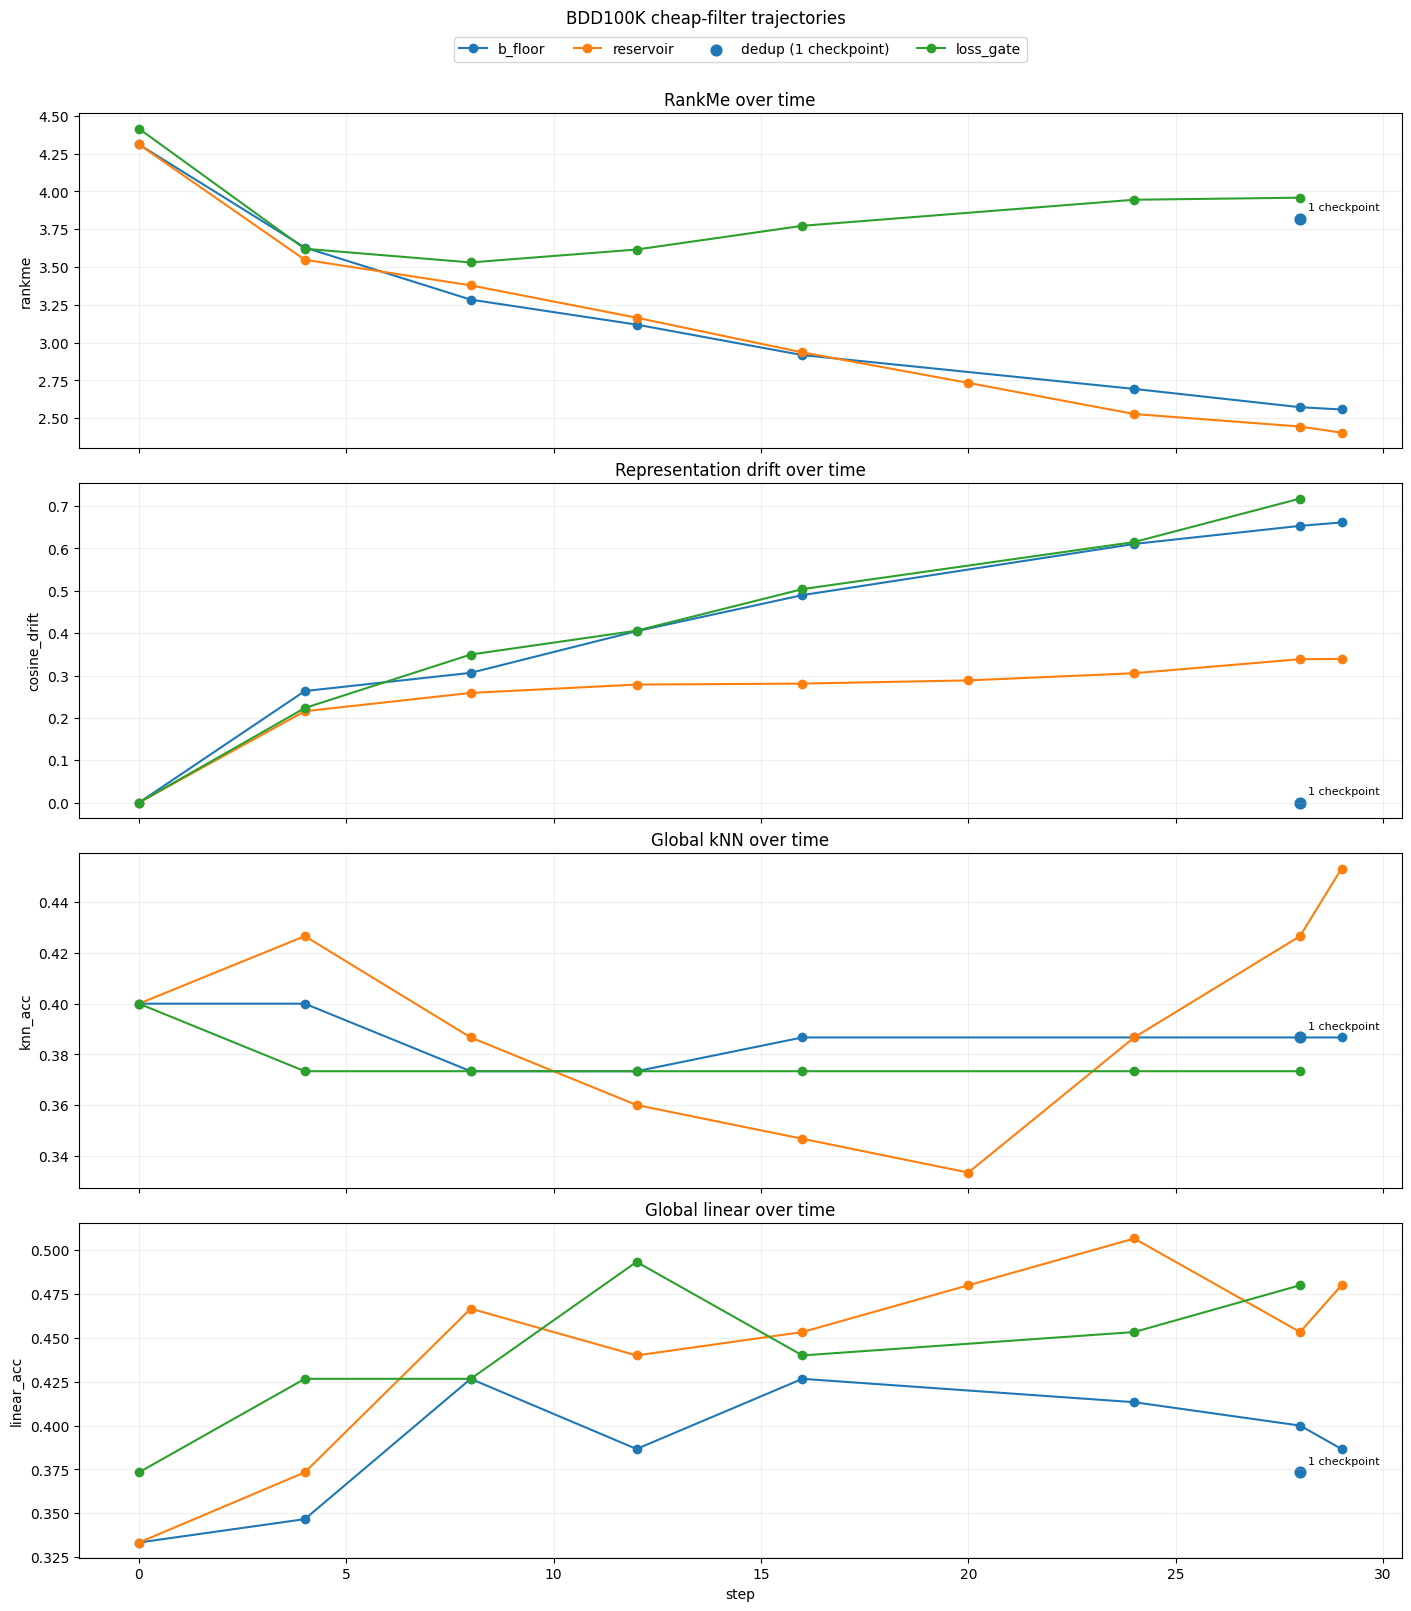

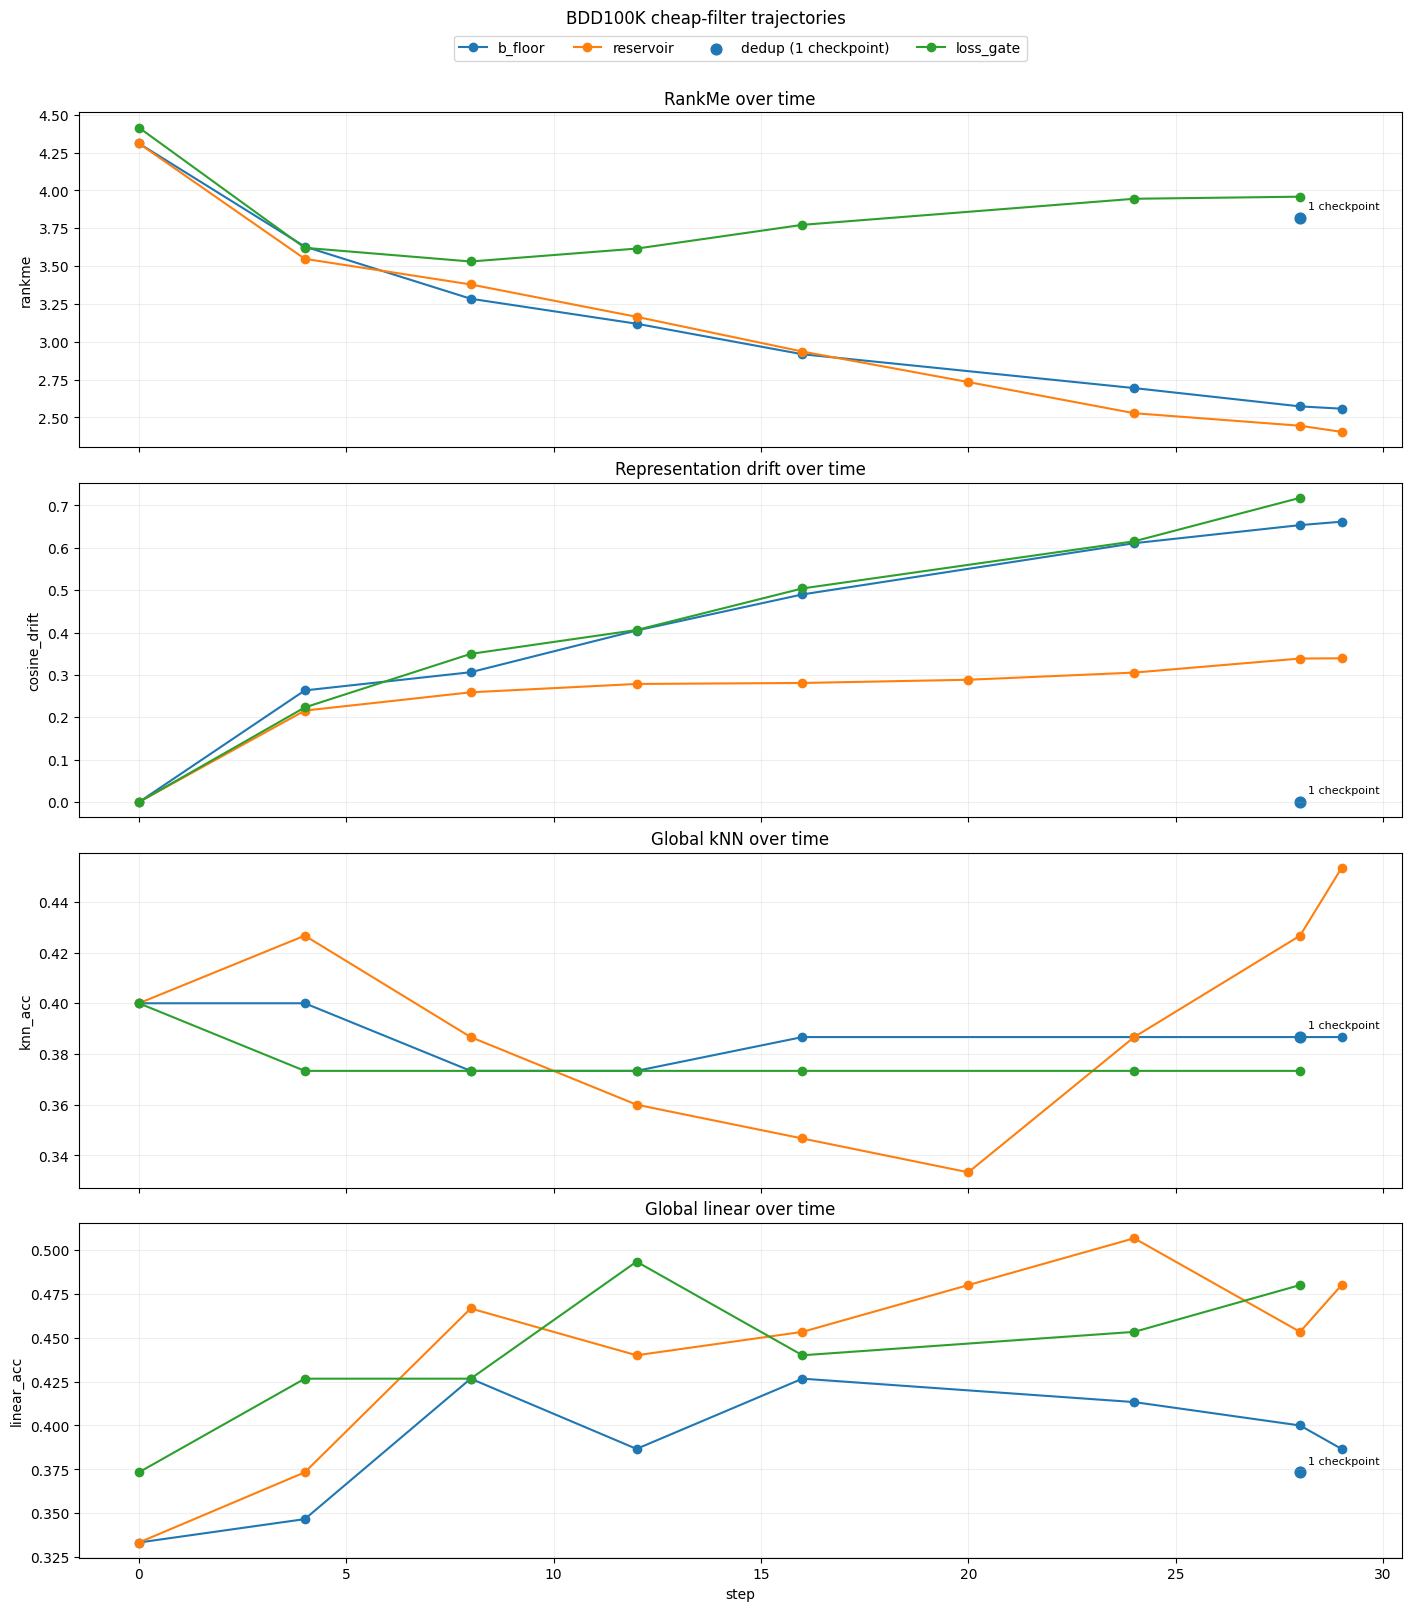

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True, constrained_layout=True)

for axis, metric, title, ylabel in [
    (axes[0], "rankme", "RankMe over time", "rankme"),
    (axes[1], "cosine_drift", "Representation drift over time", "cosine_drift"),
    (axes[2], "knn_acc", "Global kNN over time", "knn_acc"),
    (axes[3], "linear_acc", "Global linear over time", "linear_acc"),
]:
    for selector_name in filter_specs:
        subset = trajectory_health_df[trajectory_health_df["filter"] == selector_name].sort_values("step")
        if subset.empty:
            continue
        label = selector_name
        if len(subset) == 1:
            row = subset.iloc[0]
            axis.scatter([row["step"]], [row[metric]], s=60, label=f"{label} (1 checkpoint)")
            axis.annotate(
                "1 checkpoint",
                (row["step"], row[metric]),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=8,
            )
            continue
        axis.plot(subset["step"], subset[metric], marker="o", linewidth=1.5, label=label)
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.2)

axes[-1].set_xlabel("step")
axes[0].legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.25))
fig.suptitle("BDD100K cheap-filter trajectories")
fig

In [10]:
trajectory_runs = {}
trajectory_summaries = []
trajectory_health_rows = []

for selector_name in filter_specs:
    arm, summary = run_selector(selector_name)
    trajectory_runs[selector_name] = arm
    trajectory_summaries.append({"filter": selector_name, **summary})
    for checkpoint_index, record in enumerate(arm.health):
        trajectory_health_rows.append(
            {
                "filter": selector_name,
                "checkpoint_index": checkpoint_index,
                "step": record["step"],
                "rankme": record.get("rankme"),
                "cosine_drift": record.get("cosine_drift"),
                "knn_acc": record.get("knn_acc"),
                "linear_acc": record.get("linear_acc"),
                "loss": record.get("loss"),
            }
        )

trajectory_summary_df = pd.DataFrame(trajectory_summaries).set_index("filter")
trajectory_health_df = pd.DataFrame(trajectory_health_rows)
trajectory_summary_df[["keep_fraction", "final_knn_acc", "final_linear_acc", "final_rankme", "final_cosine_drift", "min_loss"]]

,keep_fraction,final_knn_acc,final_linear_acc,final_rankme,final_cosine_drift,min_loss
filter,,,,,,
b_floor,1.000000,0.373333,0.440000,2.550809,0.437693,-0.743611
reservoir,2.165829,0.440000,0.493333,2.387533,0.334104,-0.694461
dedup,0.090452,0.386667,0.373333,3.818027,0.000000,-0.092782
loss_gate,0.502513,0.346667,0.480000,3.418849,0.937907,-0.487363


In [11]:
summary_bars = trajectory_summary_df[["keep_fraction", "final_knn_acc", "final_linear_acc", "final_rankme", "final_cosine_drift"]]
summary_bars

,keep_fraction,final_knn_acc,final_linear_acc,final_rankme,final_cosine_drift
filter,,,,,
b_floor,1.000000,0.373333,0.440000,2.550809,0.437693
reservoir,2.165829,0.440000,0.493333,2.387533,0.334104
dedup,0.090452,0.386667,0.373333,3.818027,0.000000
loss_gate,0.502513,0.346667,0.480000,3.418849,0.937907


## Trajectory comparison across all cheap filters

The summary bars are useful, but the phase-relevant question is whether each filter changes the *path* of training, not just the final point.

The next cells rerun the four cheap filters under the same capped BDD setup and turn the health logs into one shared comparison table and one faceted trajectory plot.